In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import os
os.chdir('/content/drive/Shared drives/Spring Analytics Showdown/Challenge + Dataset/')

In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    classification_report
)

import statsmodels.formula.api as smf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [24]:
df = pd.read_csv("final_df.csv")

In [25]:
df['crop_class_name'] = (
    df['crop_class_name']
    .str.lower()
    .str.strip()
)

In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(0)

In [27]:
df = df[df['package_hectares'] > 0]
df = df[df['total_weight'] >= 0]

In [28]:
input_cols = [
    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

df['input_count'] = df[input_cols].sum(axis=1)

In [29]:
df['yield_per_hectare'] = (
    df['total_weight'] /
    df['package_hectares']
)

In [30]:
df['total_repayment'] = (
    df['package_cash_repayment'] +
    df['package_in_kind_repayment']
)

In [31]:
df['grade_a_ratio'] = (
    df['grade_a_weight'] /
    df['total_weight']
)

df['grade_a_ratio'] = df['grade_a_ratio'].fillna(0)

# **1**

In [32]:
#target = 'yield_per_hectare'
target = 'total_weight'

In [33]:
num_features = [

    'number_seasons',
    'package_hectares',

    'initial_down_payment_value',

    'package_cash_repayment',
    'package_in_kind_repayment',

    'input_count',

    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'

]

cat_features = [

    'crop_class_name',
    'association',
    'district_name',
    'region_name',
    'agroecological_zone'

]

In [34]:
X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, num_features),

        ('cat', categorical_transformer, cat_features)

    ]
)

In [36]:
rf_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))

])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [37]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 554.0111081667474
MAE: 283.81343082049835
R²: 0.2048005409954161


In [38]:
feature_names = rf_model.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = rf_model.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({

    'feature': feature_names,
    'importance': importances

})

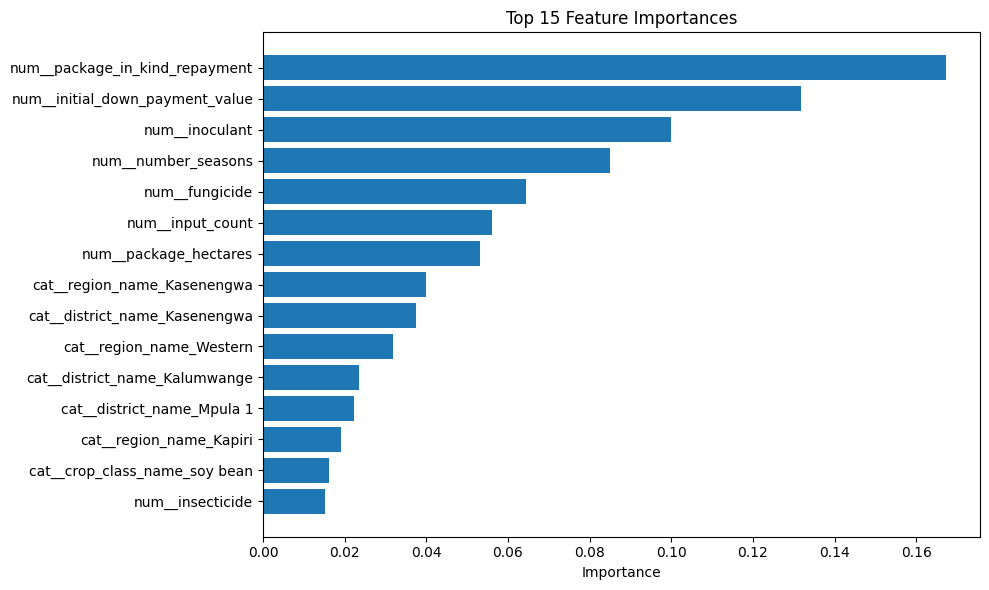

In [57]:
importance_df = pd.DataFrame({

    'feature': feature_names,
    'importance': importances

})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['feature'],
    importance_df['importance']
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [58]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_actual,
    y_pred_actual,
    alpha=0.6
)

plt.plot(
    [0, y_test_actual.max()],
    [0, y_test_actual.max()],
    linestyle='--'
)

plt.xlabel("Actual Total Weight")
plt.ylabel("Predicted Total Weight")

plt.title("Actual vs Predicted")

plt.show()

NameError: name 'y_test_actual' is not defined

<Figure size 700x700 with 0 Axes>

# **2**

In [43]:
df['yield_per_hectare'] = (
    df['total_weight'] /
    df['package_hectares']
)

In [44]:
df = df.replace([np.inf, -np.inf], np.nan)

df = df[df['yield_per_hectare'].notna()]

In [45]:
input_cols = [

    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

for col in input_cols:

    print("\n====================")
    print(col.upper())
    print("====================")

    print(

        df.groupby(col)['yield_per_hectare']
        .mean()

    )


FERTILIZER
fertilizer
0.00     755.689044
0.25    1503.449275
0.50    1048.875620
0.75    1343.809524
1.00    1246.542698
1.25     226.666667
1.50     727.386905
Name: yield_per_hectare, dtype: float64

FUNGICIDE
fungicide
0.0    761.625995
0.5    840.478338
1.0    779.815064
1.5    623.160498
2.0    534.702911
2.5    386.889832
3.0    370.190476
3.5    360.285714
4.0    255.580808
4.5     88.888889
5.0    111.300000
6.0     42.666667
6.5    207.692308
Name: yield_per_hectare, dtype: float64

GYPSUM
gypsum
0.0    829.118444
0.5    349.635253
1.0    268.485901
1.5    281.109367
2.0    301.724138
2.5    119.400000
3.0     56.500000
4.0    149.750000
4.5    111.333333
5.0     61.000000
7.0    217.000000
9.0    102.000000
Name: yield_per_hectare, dtype: float64

INOCULANT
inoculant
0.00      545.062411
0.25     1204.067098
0.50      758.742456
0.75      953.139665
1.00      720.179827
1.25      860.472727
1.50      605.349525
1.75     1581.904762
2.00      505.493873
2.50      458.720848


In [46]:
interaction_model = smf.ols(

    formula='''
    yield_per_hectare ~
    fertilizer +
    package_hectares +
    fertilizer:package_hectares
    ''',

    data=df

).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:      yield_per_hectare   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     157.0
Date:                Sun, 10 May 2026   Prob (F-statistic):          1.55e-100
Time:                        23:03:07   Log-Likelihood:            -1.5809e+05
No. Observations:               18947   AIC:                         3.162e+05
Df Residuals:                   18943   BIC:                         3.162e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

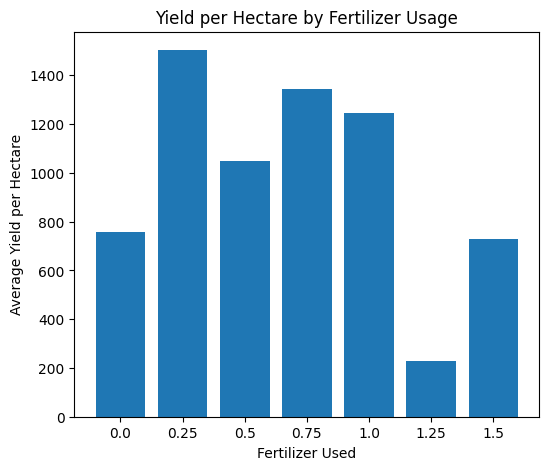

In [47]:
fert_yield = df.groupby(
    'fertilizer'
)['yield_per_hectare'].mean()

plt.figure(figsize=(6,5))

plt.bar(
    fert_yield.index.astype(str),
    fert_yield.values
)

plt.xlabel("Fertilizer Used")
plt.ylabel("Average Yield per Hectare")

plt.title("Yield per Hectare by Fertilizer Usage")

plt.show()

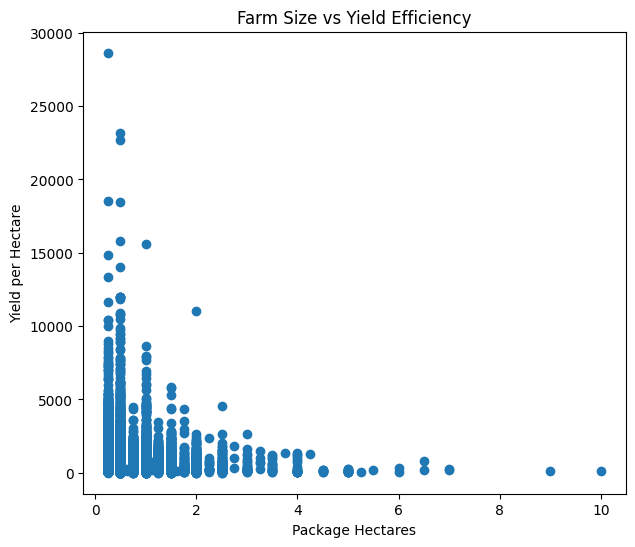

In [48]:
plt.figure(figsize=(7,6))

plt.scatter(
    df['package_hectares'],
    df['yield_per_hectare']
)

plt.xlabel("Package Hectares")
plt.ylabel("Yield per Hectare")

plt.title("Farm Size vs Yield Efficiency")

plt.show()

# **3**

In [49]:
threshold = df['yield_per_hectare'].quantile(0.25)

df['low_yield'] = (
    df['yield_per_hectare'] < threshold
).astype(int)

In [50]:
risk_features = [

    'number_seasons',
    'package_hectares',
    'initial_down_payment_value',

    'input_count',

    'fertilizer',
    'fungicide',
    'gypsum',
    'inoculant',
    'insecticide',
    'lime',
    'seed_guard'
]

X_risk = df[risk_features]

y_risk = df['low_yield']

In [51]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42
)

In [52]:
risk_model = RandomForestClassifier(

    n_estimators=200,
    random_state=42
)

risk_model.fit(X_train_r, y_train_r)

RandomForestClassifier(n_estimators=200, random_state=42)

In [53]:
y_pred_risk = risk_model.predict(X_test_r)

y_prob_risk = risk_model.predict_proba(X_test_r)[:,1]

In [54]:
print(classification_report(
    y_test_r,
    y_pred_risk
))

auc = roc_auc_score(
    y_test_r,
    y_prob_risk
)

print("AUC SCORE:", auc)

              precision    recall  f1-score   support

           0       0.83      0.97      0.90      3012
           1       0.69      0.23      0.35       778

    accuracy                           0.82      3790
   macro avg       0.76      0.60      0.62      3790
weighted avg       0.80      0.82      0.78      3790

AUC SCORE: 0.8160197683985566


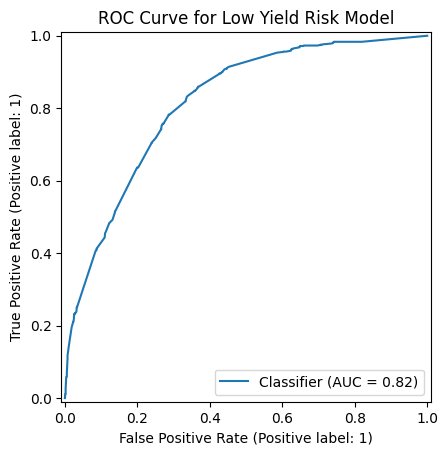

In [55]:
RocCurveDisplay.from_predictions(
    y_test_r,
    y_prob_risk
)

plt.title("ROC Curve for Low Yield Risk Model")

plt.show()

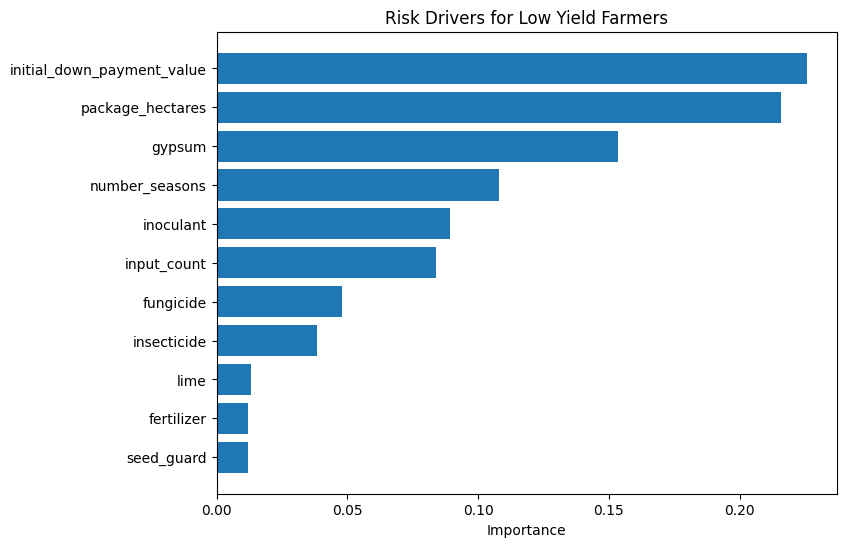

In [56]:
importance_df_risk = pd.DataFrame({

    'feature': risk_features,

    'importance': risk_model.feature_importances_

})

importance_df_risk = importance_df_risk.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    importance_df_risk['feature'],
    importance_df_risk['importance']
)

plt.gca().invert_yaxis()

plt.title("Risk Drivers for Low Yield Farmers")

plt.xlabel("Importance")

plt.show()